In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


/kaggle/input/train.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv
/kaggle/input/playground-series-s3e18/train.csv
/kaggle/input/playground-series-s3e18/description.md
/kaggle/input/playground-series-s3e18/sample_submission.csv.zip
/kaggle/input/playground-series-s3e18/test.csv.zip
/kaggle/input/playground-series-s3e18/train.csv.zip
/kaggle/input/playground-series-s3e18/test.csv
/kaggle/input/playground-series-s3e18/sample_submission.csv


In [2]:
import pandas as pd
df_train = pd.read_csv("/kaggle/input/playground-series-s3e18/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s3e18/test.csv")
sample_submission = pd.read_csv("/kaggle/input/playground-series-s3e18/sample_submission.csv")


In [3]:
df_train.head()


,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2,EC1,EC2,EC3,EC4,EC5,EC6
0,3305,212.928441,6.270857,3.431698,4.045502,1.811731,2.272429,1.619489,0.828835,7.822697,...,13.825658,36.819857,0,0,1,1,0,1,0,0
1,8217,221.694355,4.060660,3.548618,3.548618,2.499652,2.499652,1.607504,0.883813,17.980451,...,9.589074,39.833333,2,2,1,0,0,1,0,0
2,12616,159.130752,4.414719,2.801636,2.801636,2.676274,2.676274,1.204209,0.361282,12.011146,...,11.215359,33.500000,1,1,1,1,0,0,0,0
3,10153,1239.282494,16.098662,10.151117,10.151117,11.008637,11.008637,7.914542,3.408511,5.969305,...,9.589074,73.500000,1,1,1,1,0,0,0,0
4,9564,574.170559,8.417121,5.143525,5.143525,3.478542,3.478542,2.264463,2.087653,5.969305,...,4.794537,39.166667,1,1,1,0,0,1,0,0


findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Fon

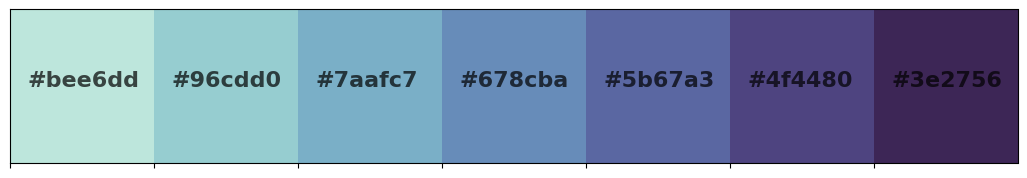

In [4]:
# Create palette

my_palette = sns.cubehelix_palette(n_colors = 7, start=.46, rot=-.45, dark = .2, hue=0.95)
sns.palplot(my_palette)
plt.gcf().set_size_inches(13,2)

for idx,values in enumerate(my_palette.as_hex()):
    plt.text(idx-0.375,0, my_palette.as_hex()[idx],{'font': "Courier New", 'size':16, 'weight':'bold','color':'black'}, alpha =0.7)
plt.gcf().set_facecolor('white')

plt.show()


In [5]:
df_train.describe().T


,count,mean,std,min,25%,50%,75%,max
id,13354.0,7430.046054,4280.726674,0.000000,3725.250000,7424.500000,11138.750000,14837.000000
BertzCT,13354.0,515.344063,541.590240,0.000000,149.874524,292.455280,652.281490,4069.959780
Chi1,13354.0,9.135106,6.811711,0.000000,4.680739,6.494089,11.170340,69.551167
Chi1n,13354.0,5.854336,4.641652,0.000000,2.854294,4.059093,7.486482,50.174588
Chi1v,13354.0,6.741385,5.859587,0.000000,2.932842,4.392859,8.527859,53.431954
Chi2n,13354.0,4.434309,3.759906,0.000000,1.949719,2.970427,5.788793,32.195368
Chi2v,13354.0,5.251854,4.914257,0.000000,2.037238,3.261677,6.621896,34.579313
Chi3v,13354.0,3.416554,3.425819,0.000000,1.162568,1.951087,4.502070,22.589276
Chi4n,13354.0,1.772391,1.860338,0.000000,0.508512,1.077096,2.540348,16.072810
EState_VSA1,13354.0,29.207586,31.755738,0.000000,5.969305,17.353601,44.876559,363.705954


In [6]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 13354 non-null  int64  
 1   BertzCT            13354 non-null  float64
 2   Chi1               13354 non-null  float64
 3   Chi1n              13354 non-null  float64
 4   Chi1v              13354 non-null  float64
 5   Chi2n              13354 non-null  float64
 6   Chi2v              13354 non-null  float64
 7   Chi3v              13354 non-null  float64
 8   Chi4n              13354 non-null  float64
 9   EState_VSA1        13354 non-null  float64
 10  EState_VSA2        13354 non-null  float64
 11  ExactMolWt         13354 non-null  float64
 12  FpDensityMorgan1   13354 non-null  float64
 13  FpDensityMorgan2   13354 non-null  float64
 14  FpDensityMorgan3   13354 non-null  float64
 15  HallKierAlpha      13354 non-null  float64
 16  HeavyAtomMolWt     133

In [7]:
df_train[['MaxAbsEStateIndex','MinEStateIndex']]


,MaxAbsEStateIndex,MinEStateIndex
0,10.893972,-4.947221
1,9.226852,-1.165509
2,10.636065,-1.500880
3,11.526326,-1.439086
4,10.484861,-0.985000
...,...,...
13349,10.724019,-0.355278
13350,10.037773,-1.004630
13351,10.249692,-1.006481
13352,10.101852,-1.420185


In [8]:
df_train.drop('id', axis=1, inplace = True)
df_test.drop('id', axis=1, inplace = True)


In [9]:
target_col1 = 'EC1'
target_col2 = 'EC2'
num_cols = [
    'BertzCT',
    'Chi1','Chi1n','Chi1v','Chi2n','Chi2v','Chi3v','Chi4n','EState_VSA1','EState_VSA2',
    'ExactMolWt','FpDensityMorgan1','FpDensityMorgan2','FpDensityMorgan3',
    'HallKierAlpha','HeavyAtomMolWt','Kappa3','MaxAbsEStateIndex','MinEStateIndex','NumHeteroatoms',
    'PEOE_VSA10','PEOE_VSA14','PEOE_VSA6','PEOE_VSA7','PEOE_VSA8','SMR_VSA10','SMR_VSA5',
    'SlogP_VSA3','VSA_EState9',
]
binary_cols = [
    'EC1',
    'EC2',
    'EC3',
    'EC4',
    'EC5',
    'EC6'
]
cat_cols = df_test.select_dtypes(include=['object']).columns.tolist()


print(f'[INFO] Shapes:'
      f'\n train: {df_train.shape}'
      f'\n test: {df_test.shape}\n')

print(f'[INFO] Any missing values:'

      f'\n train: {df_train.isna().any().any()}'
      f'\n test: {df_test.isna().any().any()}')


[INFO] Shapes:
 train: (13354, 37)
 test: (1484, 31)

[INFO] Any missing values:
 train: False
 test: False


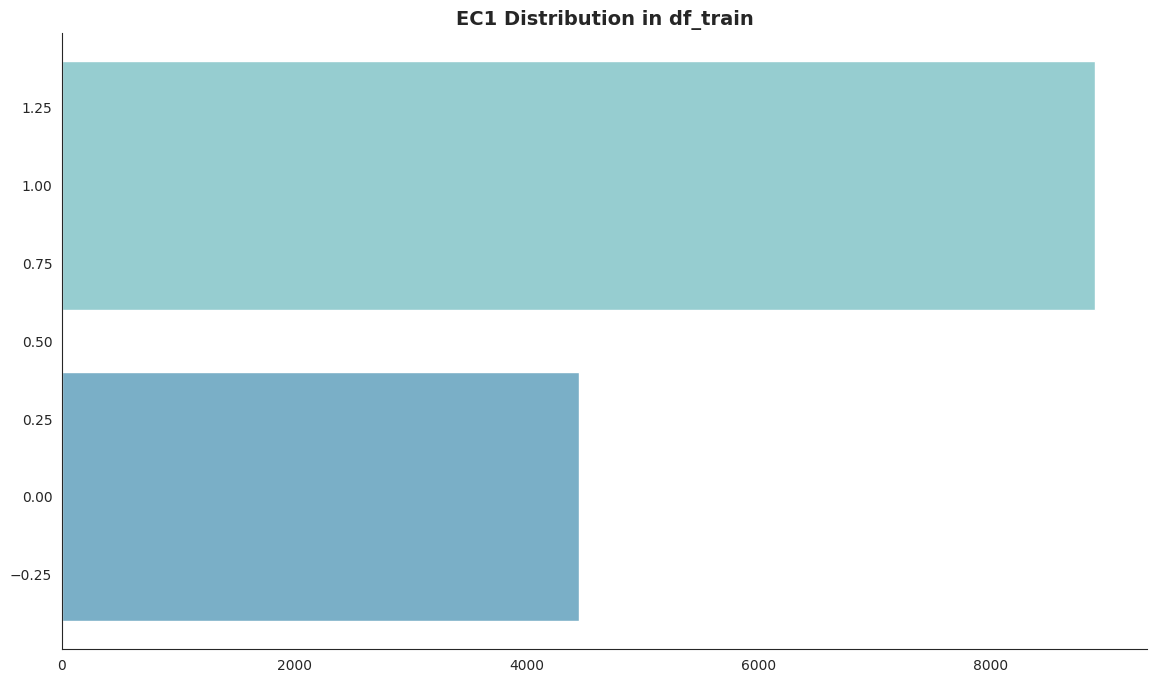

In [10]:
# create figure and set style with white background
plt.figure(figsize = (14, 8))
sns.set_style('white')

# set colors
colors = my_palette

# plot
plt.barh(df_train[target_col1].value_counts().index,
        df_train[target_col1].value_counts(),
        color = colors[1:3])

# set title
plt.title('EC1 Distribution in df_train', fontsize = 14, fontweight = 'bold')

# remove spines from plot
sns.despine()

# display all open figures
plt.show()


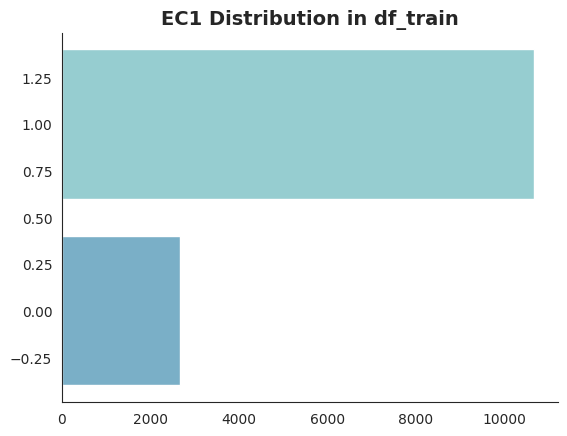

In [11]:
# plot
plt.barh(df_train[target_col2].value_counts().index,
        df_train[target_col2].value_counts(),
        color = colors[1:3])

# set title
plt.title('EC1 Distribution in df_train', fontsize = 14, fontweight = 'bold')

# remove spines from plot
sns.despine()

# display all open figures
plt.show()


In [12]:
!pip install ludwig


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.1/98.1 kB 5.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraint

In [13]:
from sklearn.preprocessing import power_transform
df_tr_copy = df_train.copy()
df_tst_copy = df_test.copy()

df_tr_copy.iloc[:,:] = power_transform(df_tr_copy.iloc[:,:] , method = "yeo-johnson")
df_tst_copy.iloc[:,:] = power_transform(df_tst_copy.iloc[:,:] , method = "yeo-johnson")


/tmp/ipykernel_11/145370977.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.49909148 -0.23689306 -0.52017956 ... -0.52017956 -0.23689306
  0.49909148]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_tr_copy.iloc[:,:] = power_transform(df_tr_copy.iloc[:,:] , method = "yeo-johnson")
/tmp/ipykernel_11/145370977.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.76452534  1.56408959  1.22353491 ...  1.22353491  1.22353491
  1.22353491]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_tr_copy.iloc[:,:] = power_transform(df_tr_copy.iloc[:,:] , method = "yeo-johnson")
/tmp/ipykernel_11/145370977.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.76619094  1.56336661  1.220064

In [14]:
def out_iqr(df):
#     global lower,upper
    columns = df.columns 
    iqrs,lower_out , upper_out = [],[],[]
    for column in columns:
        q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
        # calculate the IQR
        iqr = q75 - q25
        # calculate the outlier cutoff
        cut_off = iqr * 1.5
        # calculate the lower and upper bound value
        lower, upper = q25 - cut_off, q75 + cut_off
#         print('The IQR is',iqr)
#         print('The lower bound value is', lower)
#         print('The upper bound value is', upper)
        # Calculate the number of records below and above lower and above bound value respectively
        df1 = df[df[column] > upper].shape[0]
        df2 = df[df[column] < lower].shape[0]
        iqrs.append(iqr)
        upper_out.append(df1)
        lower_out.append(df2)
    return pd.DataFrame(
        data = {
            "columns": df.columns,
            "iqr":iqrs,
            "lower_outliers":lower_out,
            "upper_outliers": upper_out,
        }
    ).style.background_gradient(axis=0, cmap="Greens")


In [15]:
out_iqr(df_tr_copy)


/usr/local/lib/python3.11/dist-packages/IPython/core/formatters.py:345: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()
/usr/local/lib/python3.11/dist-packages/IPython/core/formatters.py:345: FutureWarning: RangeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,columns,iqr,lower_outliers,upper_outliers
0,BertzCT,1.321586,181,10
1,Chi1,1.290858,149,4
2,Chi1n,1.311414,145,4
3,Chi1v,1.355721,136,1
4,Chi2n,1.349590,0,1
5,Chi2v,1.356701,0,0
6,Chi3v,1.392904,0,0
7,Chi4n,1.527379,0,0
8,EState_VSA1,1.388473,0,2
9,EState_VSA2,1.874473,0,0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

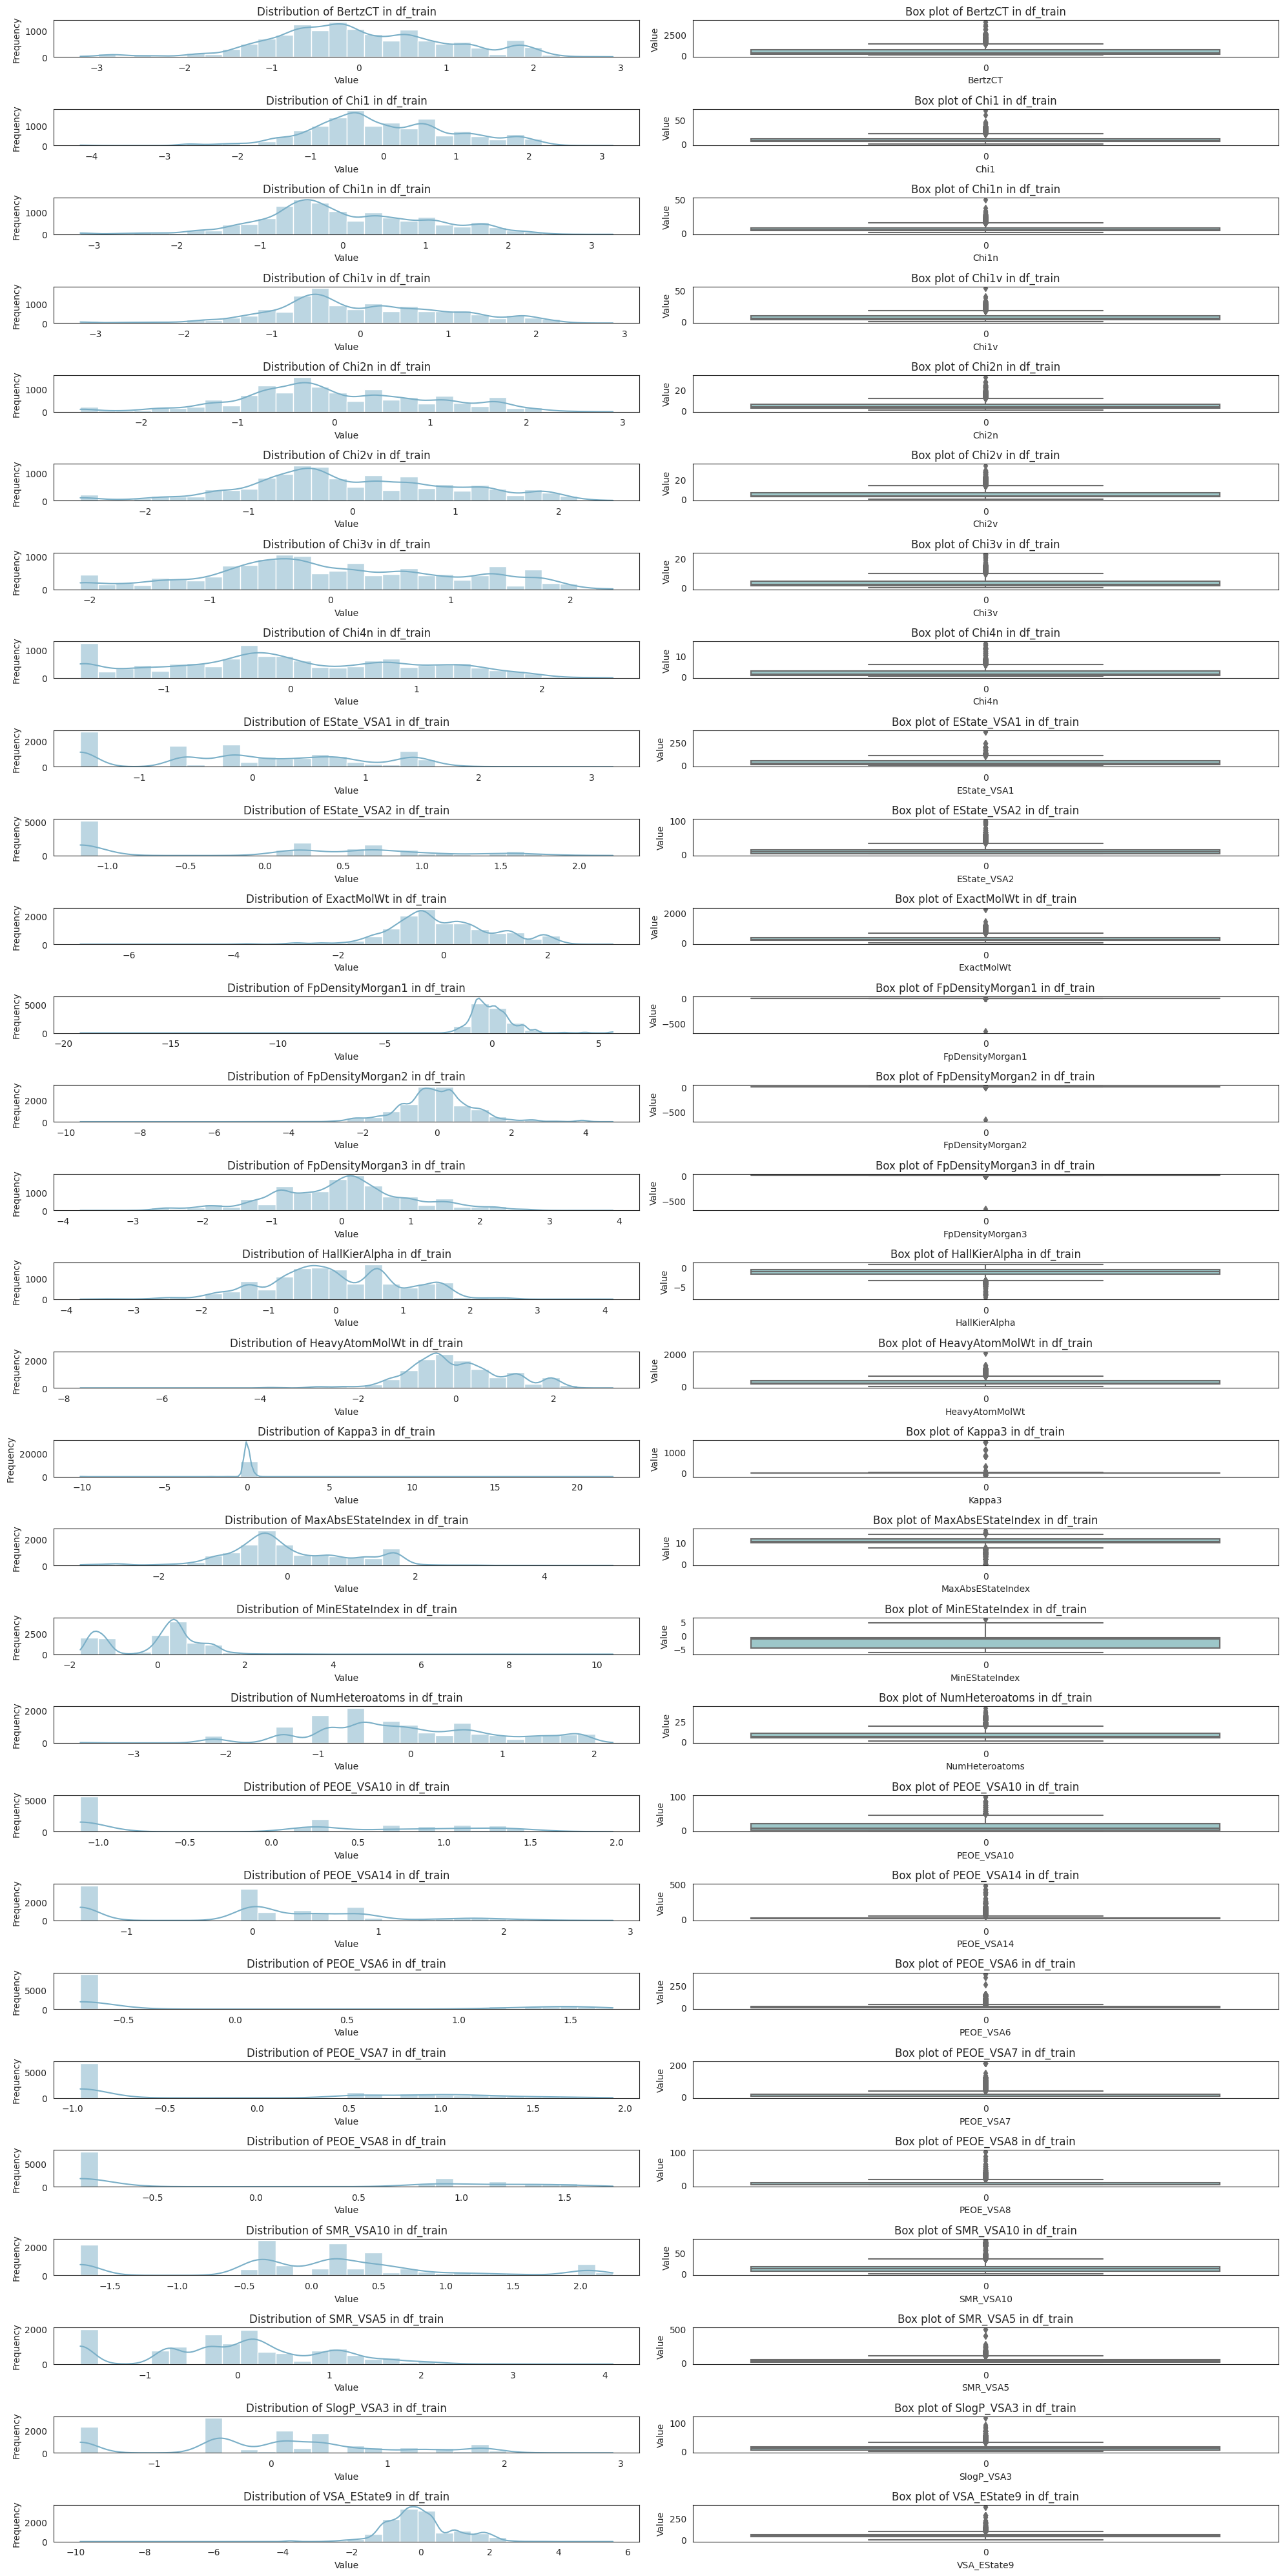

In [16]:
# Check basic statistics for numerical columns in train data
numerical_columns = num_cols

# Create subplots
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(20, 40))

# Plot the histograms and box plots
for i, column in enumerate(numerical_columns):
    # Histogram
    sns.histplot(df_tr_copy[column], bins=30, kde=True, ax=axes[i, 0], color = my_palette[2])
    axes[i, 0].set_title(f'Distribution of {column} in df_train')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(df_train[column], ax=axes[i, 1], color = my_palette[1])
    axes[i, 1].set_title(f'Box plot of {column} in df_train')
    axes[i, 1].set_xlabel(column)
    axes[i, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()


In [17]:
import ludwig
from ludwig.api import LudwigModel
import logging


<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.Tensor size changed, may indicate binary incompatibility. Expected 64 from C header, got 80 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.ChunkedArray size changed, may indicate binary incompatibility. Expected 64 from C header, got 72 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib._Tabular size changed, may indicate binary incompatibility. Expected 24 from C header, got 32 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.Table size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.NativeFile size changed, may indicate binary incompatibility. Expected 96 from C header, got 104 from PyObject
<frozen importlib._bootstrap>:241: RuntimeWarning: pyarrow.lib.BufferedInputStream size changed, may indicate binary incompatibility. Expected 

OSError: /usr/local/lib/python3.11/dist-packages/torchtext/lib/libtorchtext.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs

In [18]:
def configs(par, sample_key, sample_item):
    config = {'combiner': {'dropout': 0.3,
                  'num_fc_layers': 3,
                  'output_size': 256,

                  'type': 'concat'},

     'input_features': [{'name': 'BertzCT', 'type': 'number'},
                        {'name': 'Chi1', 'type': 'number'},
                        {'name': 'Chi1n', 'type': 'number'},
                        {'name': 'Chi1v', 'type': 'number'},
                        {'name': 'Chi2n', 'type': 'number'},
                        {'name': 'Chi2v', 'type': 'number'},
                        {'name': 'Chi3v', 'type': 'number'},
                        {'name': 'Chi4n', 'type': 'number'},
                        {'name': 'EState_VSA1', 'type': 'number'},
                        {'name': 'EState_VSA2', 'type': 'number'},
                        {'name': 'ExactMolWt', 'type': 'number'},
                        {'name': 'FpDensityMorgan1', 'type': 'number'},
                        {'name': 'FpDensityMorgan2', 'type': 'number'},
                        {'name': 'FpDensityMorgan3', 'type': 'number'},
                        {'name': 'HallKierAlpha', 'type': 'number'},
                        {'name': 'HeavyAtomMolWt', 'type': 'number'},
                        {'name': 'Kappa3', 'type': 'number'},
                        {'name': 'MaxAbsEStateIndex', 'type': 'number'},
                        {'name': 'MinEStateIndex', 'type': 'number'},
                        {'name': 'NumHeteroatoms', 'type': 'number'},
                        {'name': 'PEOE_VSA10', 'type': 'number'},
                        {'name': 'PEOE_VSA14', 'type': 'number'},
                        {'name': 'PEOE_VSA6', 'type': 'number'},
                        {'name': 'PEOE_VSA7', 'type': 'number'},
                        {'name': 'PEOE_VSA8', 'type': 'number'},
                        {'name': 'SMR_VSA10', 'type': 'number'},
                        {'name': 'SMR_VSA5', 'type': 'number'},
                        {'name': 'SlogP_VSA3', 'type': 'number'},
                        {'name': 'VSA_EState9', 'type': 'number'},
                        {'name': 'fr_COO', 'type': 'category'},
                        {'name': 'fr_COO2', 'type': 'category'},
                        
                        



                       ],
     'output_features': [{'name': par,
                          'encoder': {
                                    'activations' : 'relu',
                                    'weights_initializer': 'xavier_uniform',},
                          'decoder': {
                                'num_fc_layers': 4,
                                'fc_activation': 'relu',
                                'output_size': 4
                          },
                          'preprocessing': {'fallback_true_label': '1'},
                          'loss': {'type': 'binary_weighted_cross_entropy'},
                          'type': 'binary'}],
     'defaults': {
        'number': {
          'preprocessing': {
            'missing_value_strategy': 'fill_with_mean',
            'normalization': 'zscore',
            sample_key : sample_item
          }
        }
     },

     'trainer': {'epochs': 40, 'optimizer': {'type': 'adam'}},

     'hyperopt':  {
            # specify parameters for the Ray Tune to executor to run the hyperparameter optimization
            'executor': {'num_samples': 8},
            # hyperparameter search space for the optimization
            'parameters': {
                        'Machine failure.decoder.num_fc_layers': {
                            'space': 'randint',
                            'lower': 2,
                            'upper': 10
                        },
                        'trainer.learning_rate': {
                            'space': 'loguniform',
                            'lower': 0.0001,
                            'upper': 0.1}
                        },
            'search_alg': {'type': 'optuna', 'random_state': 42, },
            # minimize or maximize the metric score
            'goal': 'maximize',
            # metric score to optimize
            'metric': 'roc_auc',
            # name of the output feature
            'output_feature': par,
            }        
             }
    return config

config1 = configs('EC1','oversample_minority', 0.5)

# instantiate Ludwig model object
model = LudwigModel(config=config1, logging_level=logging.INFO)


NameError: name 'LudwigModel' is not defined

In [19]:
# Trains the model. This cell might take a few minutes.
train_stats1, preprocessed_data1, output_directory1 = model.train(training_set=df_train,
                                                               test_set=df_test)


NameError: name 'model' is not defined

In [20]:
predictions1, prediction_results1 = model.predict(dataset=df_test, skip_save_predictions=False, output_directory="predictions_results")


NameError: name 'model' is not defined

In [21]:
predictions1


NameError: name 'predictions1' is not defined

In [22]:
config2 = configs('EC2','undersample_majority', 0.7)


In [23]:
# instantiate Ludwig model object
model = LudwigModel(config=config2, logging_level=logging.INFO)


NameError: name 'LudwigModel' is not defined

In [24]:
# Trains the model. This cell might take a few minutes.
train_stats2, preprocessed_data2, output_directory2 = model.train(training_set=df_train,
                                                               test_set=df_test)


NameError: name 'model' is not defined

In [25]:
predictions2, prediction_results2 = model.predict(dataset=df_test, skip_save_predictions=False, output_directory="predictions_results2")


NameError: name 'model' is not defined

In [26]:
predictions2


NameError: name 'predictions2' is not defined

In [27]:
sample_submission['EC1'] = predictions1['EC1_probabilities_True'].values
sample_submission['EC2'] = predictions2['EC2_probabilities_True'].values
sample_submission.to_csv(f'submission.csv', index=False)
sample_submission


NameError: name 'predictions1' is not defined

In [28]:
'''
	id	EC1	EC2
0	14838	0.442583	0.773034
1	14839	0.782714	0.834345
2	14840	0.776329	0.745320
3	14841	0.698985	0.832561
4	14842	0.766535	0.741735
...	...	...	...
9888	24726	0.592066	0.754180
9889	24727	0.743892	0.925888
9890	24728	0.397900	0.829724
9891	24729	0.372347	0.898844
9892	24730	0.391224	0.867007'''


'\n\tid\tEC1\tEC2\n0\t14838\t0.442583\t0.773034\n1\t14839\t0.782714\t0.834345\n2\t14840\t0.776329\t0.745320\n3\t14841\t0.698985\t0.832561\n4\t14842\t0.766535\t0.741735\n...\t...\t...\t...\n9888\t24726\t0.592066\t0.754180\n9889\t24727\t0.743892\t0.925888\n9890\t24728\t0.397900\t0.829724\n9891\t24729\t0.372347\t0.898844\n9892\t24730\t0.391224\t0.867007'